# 04 - Modeling (Bank Marketing)

Mục tiêu:
- So sánh ít nhất 3 model: LogisticRegression, RandomForest, SVC
- Báo cáo accuracy/precision/recall/f1/roc_auc và confusion matrix
- Lưu model tốt nhất


=== LogisticRegression ===
              precision    recall  f1-score   support

           0       0.96      0.80      0.87       801
           1       0.33      0.77      0.46       104

    accuracy                           0.79       905
   macro avg       0.65      0.78      0.67       905
weighted avg       0.89      0.79      0.82       905



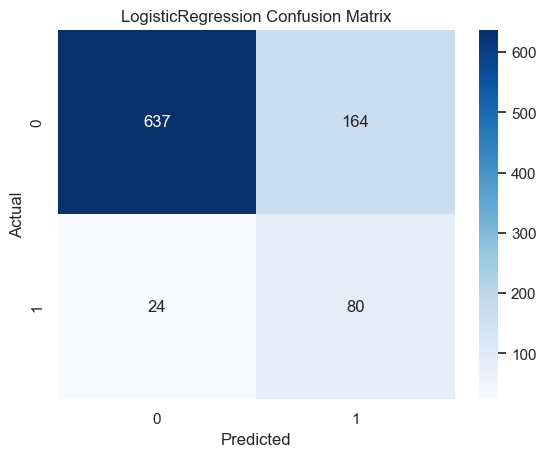


=== RandomForest ===
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       801
           1       0.55      0.17      0.26       104

    accuracy                           0.89       905
   macro avg       0.72      0.58      0.60       905
weighted avg       0.86      0.89      0.86       905



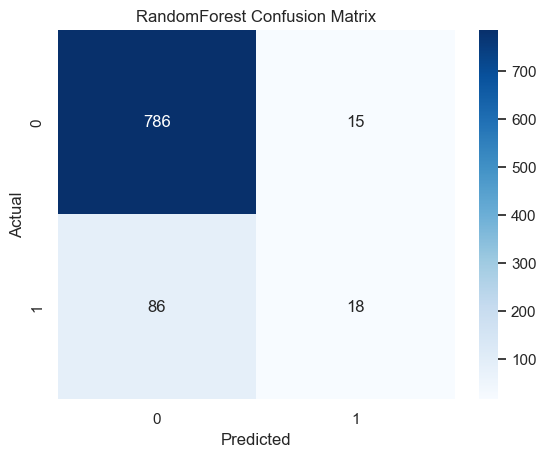


=== SVC ===
              precision    recall  f1-score   support

           0       0.96      0.85      0.90       801
           1       0.39      0.75      0.51       104

    accuracy                           0.83       905
   macro avg       0.67      0.80      0.71       905
weighted avg       0.90      0.83      0.86       905



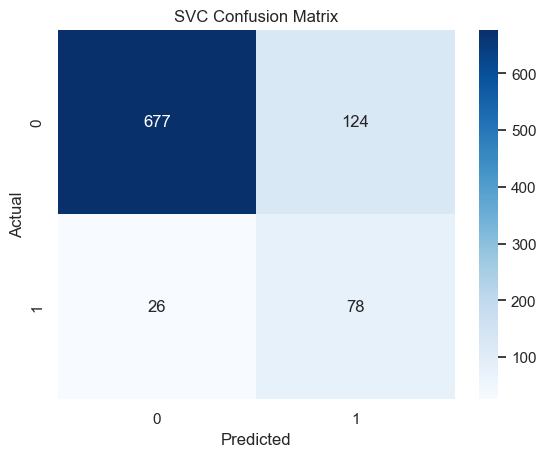


Summary results:
                    accuracy  precision    recall        f1   roc_auc
model                                                                
LogisticRegression  0.792265   0.327869  0.769231  0.459770  0.856381
RandomForest        0.888398   0.545455  0.173077  0.262774  0.906781
SVC                 0.834254   0.386139  0.750000  0.509804  0.867635


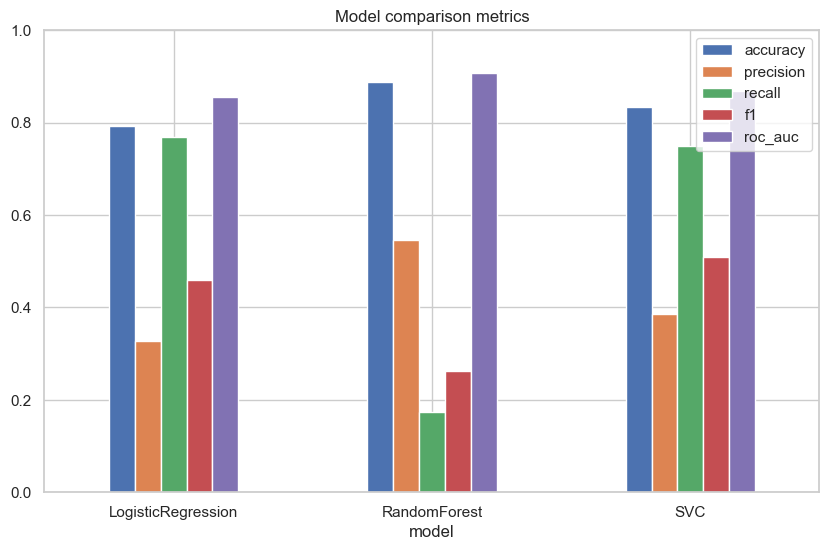

Best model on F1: SVC
Saved best model and scaler.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
import joblib

sns.set(style='whitegrid')

df = pd.read_csv('../data/processed/bank_clean.csv')

X = df.drop(columns=['y'])
y = df['y']

# train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# scale numeric features
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'SVC': SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else np.nan,
    }
    results.append(metrics)

    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred, zero_division=0))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

results_df = pd.DataFrame(results).set_index('model')
print('\nSummary results:')
print(results_df)

# Vẽ so sánh
results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].plot(kind='bar', figsize=(10, 6), rot=0)
plt.title('Model comparison metrics')
plt.ylim(0, 1)
plt.show()

# Lưu model tốt nhất theo F1
best_model_name = results_df['f1'].idxmax()
print('Best model on F1:', best_model_name)
joblib.dump(models[best_model_name], '../outputs/models/best_model.pkl')
joblib.dump(scaler, '../outputs/models/scaler.pkl')
print('Saved best model and scaler.')